# DL069 可执行实验

代码单元按序真实运行，输出保存在notebook_outputs。

In [1]:
from pathlib import Path
import sys,json,numpy as np,torch
import experiment as e
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image,display
def show(fig):
    b=BytesIO();fig.savefig(b,format='png',dpi=140,bbox_inches='tight');display(Image(data=b.getvalue()));plt.close(fig)
torch.set_num_threads(1)
print({'python':sys.version.split()[0],'torch':torch.__version__,'device':'CPU'})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'device': 'CPU'}


## 数据与随机源

In [2]:
x,y=e.data();print(x.shape,y.shape,e.CONFIG)

torch.Size([384, 6]) torch.Size([384]) {'data_seed': 6901, 'seed': 69, 'n_train': 256, 'n_test': 128, 'epochs': 24, 'split_epoch': 12, 'batch_size': 32, 'lr': 0.01}


## 完整语义测试

In [3]:
import unittest,test_experiment
z=unittest.TextTestRunner().run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not z.wasSuccessful():raise RuntimeError('tests failed')

.

.

.

.

----------------------------------------------------------------------
Ran 4 tests in 1.020s

OK


## 实际建立检查点与资产清单

In [4]:
r=e.run("notebook_outputs");print({k:r[k] for k in ["resume_max_parameter_gap","weights_only_max_parameter_gap","metrics","simulated_tamper_detected"]})

{'resume_max_parameter_gap': 0.0, 'weights_only_max_parameter_gap': 0.29491493105888367, 'metrics': {'continuous': {'loss': 0.1543545126914978, 'accuracy': 0.9453125}, 'resumed': {'loss': 0.1543545126914978, 'accuracy': 0.9453125}, 'weights_only': {'loss': 0.1720796823501587, 'accuracy': 0.9296875}}, 'simulated_tamper_detected': True}


## 直接画出本次训练轨迹

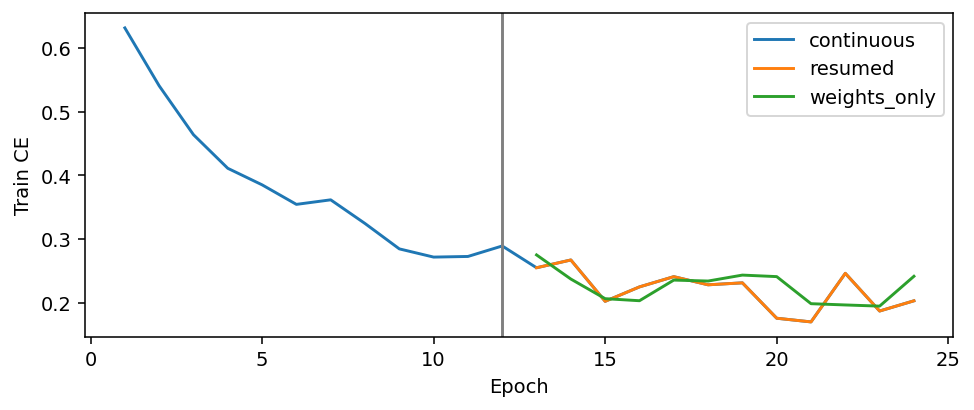

In [5]:
fig,ax=plt.subplots(figsize=(8,3))
for k in r["histories"]:
    h=r["histories"][k];ax.plot([a["epoch"] for a in h],[a["train_loss"] for a in h],label=k)
ax.axvline(12,color="gray");ax.set(xlabel="Epoch",ylabel="Train CE");ax.legend();show(fig)

## 重新加载三个终点计算指标

In [6]:
x,y=e.data()
for name,key in [("continuous","continuous"),("resumed","resumed"),("weights_only","weights_only")]:
    ck=torch.load(f"notebook_outputs/{name}_epoch24.pt",weights_only=True);m=e.model();m.load_state_dict(ck["model"]);z=e.assess(m,x,y)
    np.testing.assert_allclose(z["loss"],r["metrics"][key]["loss"],rtol=0,atol=1e-7);print(name,z)
manifest=json.loads(Path("notebook_outputs/asset_manifest.json").read_text())
if e.verify_assets("notebook_outputs",manifest):raise RuntimeError("asset hash mismatch")
print("six assets verified")

continuous {'loss': 0.1543545126914978, 'accuracy': 0.9453125}
resumed {'loss': 0.1543545126914978, 'accuracy': 0.9453125}
weights_only {'loss': 0.1720796823501587, 'accuracy': 0.9296875}
six assets verified


## 精确一致与不同轨迹

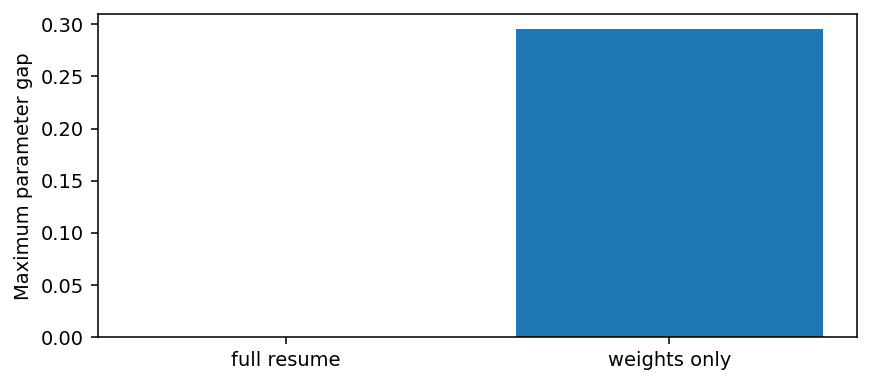

['Exact match only tested in same Python/PyTorch CPU environment with deterministic operations', 'Hash matching establishes byte integrity relative to a trusted manifest, not provenance, permission or model correctness', 'Toy exact-row deduplication does not identify semantic near-duplicates']


In [7]:
fig,ax=plt.subplots(figsize=(7,3));ax.bar(["full resume","weights only"],[r["resume_max_parameter_gap"],r["weights_only_max_parameter_gap"]]);ax.set(ylabel="Maximum parameter gap");show(fig)
print(r["limits"])